# Credit Card Customer Segmentation using Unsupervised Machine Learning

## Project Objective

This project aims to segment credit card customers based on their financial behavior using unsupervised machine learning techniques.

The workflow includes:
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Feature Engineering
- PCA (Dimensionality Reduction)
- Clustering
- Cluster Evaluation
- Streamlit Deployment
- Business Insights

## Business Goal

Customer segmentation helps financial institutions:
- identify customer behavior patterns
- improve marketing strategies
- detect risky financial behavior
- personalize financial products
- improve customer retention

## Algorithms Used

- KMeans Clustering
- Hierarchical Clustering
- DBSCAN

## Final Selected Model

DBSCAN was selected because it handled:
- outliers
- density variations
- anomalous customer behavior

more effectively than centroid-based clustering methods.

In [61]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Notebook settings
pd.set_option('display.max_columns', None)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Project Setup

This section configures notebook settings and project paths.

In [62]:
# ==========================================
# PROJECT SETUP
# ==========================================

import os
import sys

# Get project root
project_root = os.path.abspath("..")

# Add project root to system path
if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added successfully!")
print(project_root)

Project root added successfully!
C:\Users\niyas\ML\Customer-segmentation-project


In [63]:
# ==========================================
# IMPORT CUSTOM MODULES
# ==========================================
from src.utilis import (
    print_section,
    plot_histogram,
    plot_boxplot,
    plot_correlation
)

# Load Dataset

The dataset contains customer financial behavior information including:
- purchases
- payments
- balances
- cash advances
- transaction frequency
- credit utilization

In [64]:
# ==========================================
# LOAD DATA
# ==========================================

data_path = "../data/raw/CC GENERAL.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


# Initial Dataset Overview

This section examines:
- dataset shape
- column information
- missing values
- duplicate records
- statistical summary

In [65]:
# ==========================================
# DATASET SHAPE
# ==========================================

print_section("Dataset Shape")
print(df.shape)


Dataset Shape
(8950, 18)


In [66]:
# ==========================================
# FIRST 5 ROWS
# ==========================================

print_section("Dataset Preview")
df.head()


Dataset Preview


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [67]:
# ==========================================
# DATA TYPES
# ==========================================

print_section("Data Types")
df.info()


Data Types
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  

In [68]:
# ==========================================
# MISSING VALUES
# ==========================================

print_section("Missing Values")
missing_values = (df.isnull().sum().sort_values(ascending=False))

missing_values[missing_values > 0]


Missing Values


MINIMUM_PAYMENTS    313
CREDIT_LIMIT          1
dtype: int64

In [69]:
# ==========================================
# DUPLICATE RECORDS
# ==========================================

print_section("Duplicate Records")

duplicates = (
    df.duplicated().sum()
)

print(f"Duplicate rows: {duplicates}")


Duplicate Records
Duplicate rows: 0


In [70]:
# ==========================================
# STATISTICAL SUMMARY
# ==========================================

print_section("Statistical Summary")
df.describe().T


Statistical Summary


,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


# Exploratory Data Analysis (EDA)

This section analyzes customer financial behavior patterns through:
- feature distributions
- skewness analysis
- outlier detection
- correlation analysis
- dimensionality visualization

The purpose is to better understand customer behavior before clustering.

In [77]:
# ==========================================
# NUMERICAL COLUMNS
# ==========================================

numeric_cols = (
    df.select_dtypes(include=np.number)
    .columns
)
print(numeric_cols)
len(numeric_cols)

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='object')


17

# Distribution Analysis

Important financial variables were analyzed to understand:
- customer spending behavior
- transaction activity
- payment behavior
- cash advance usage

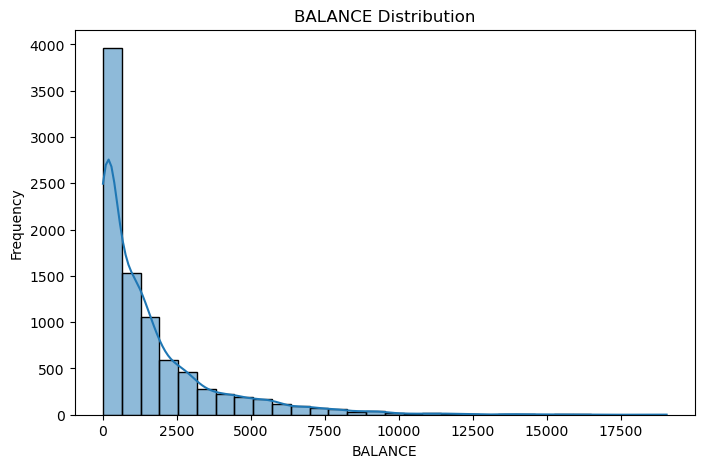

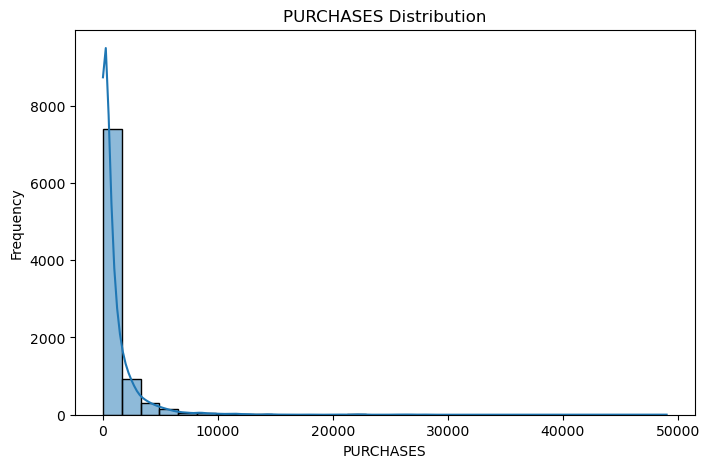

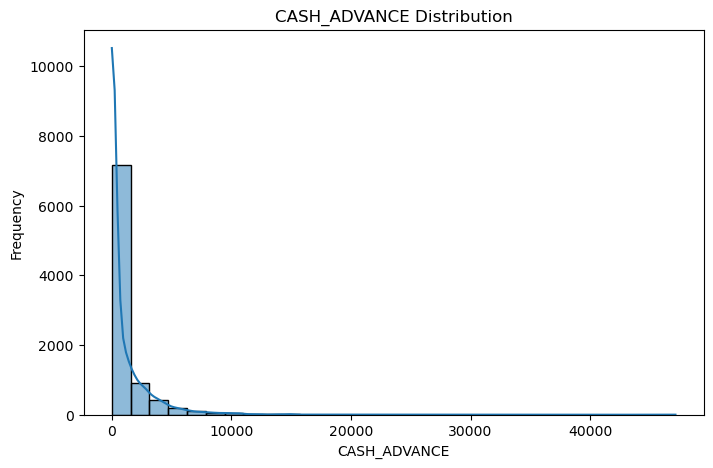

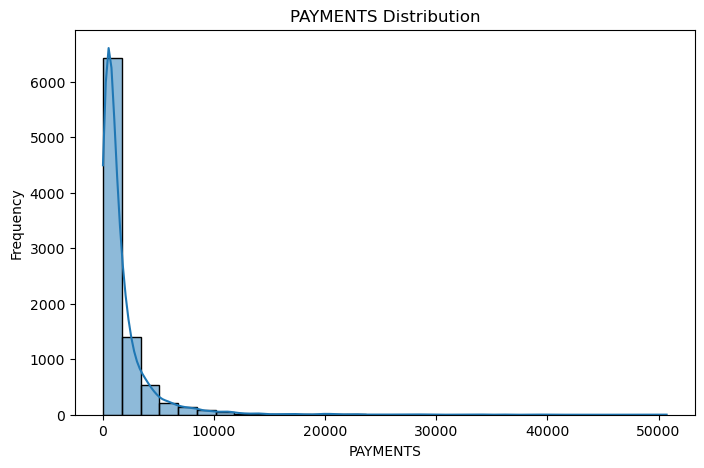

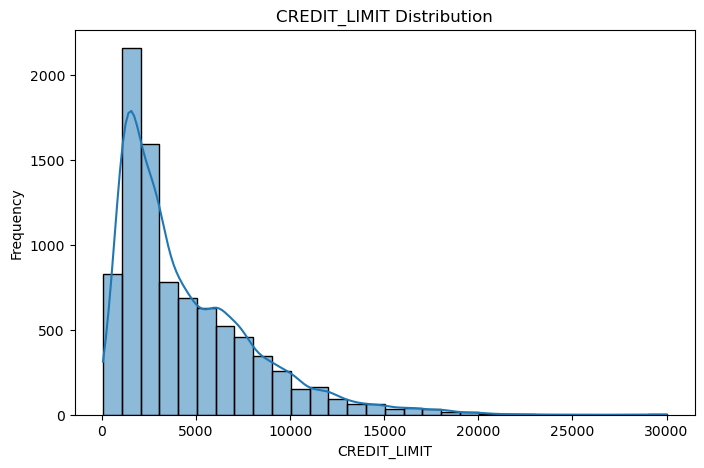

In [78]:
# ==========================================
# HISTOGRAMS
# ==========================================
important_cols = [

    'BALANCE',
    'PURCHASES',
    'CASH_ADVANCE',
    'PAYMENTS',
    'CREDIT_LIMIT'
]
for col in important_cols:
    plot_histogram(df, col)

## EDA Observation

The financial variables show highly right-skewed distributions.

This indicates:
- a small number of customers perform extremely high financial activity
- most customers maintain moderate spending behavior
- significant outliers exist in transaction-related features

These observations suggest preprocessing techniques such as:
- log transformation
- outlier handling
- robust scaling

will be necessary before clustering.

# Skewness Analysis

Skewness analysis helps identify features with highly asymmetric distributions.

Highly skewed features can negatively affect:
- clustering performance
- distance calculations
- PCA behavior

In [13]:
# ==========================================
# SKEWNESS ANALYSIS
# ==========================================

print_section("Feature Skewness")

skewness = (df[numeric_cols].skew().sort_values(ascending=False))

skewness


Feature Skewness


MINIMUM_PAYMENTS                    13.622797
ONEOFF_PURCHASES                    10.045083
PURCHASES                            8.144269
INSTALLMENTS_PURCHASES               7.299120
PAYMENTS                             5.907620
CASH_ADVANCE_TRX                     5.721298
CASH_ADVANCE                         5.166609
PURCHASES_TRX                        4.630655
BALANCE                              2.393386
PRC_FULL_PAYMENT                     1.942820
CASH_ADVANCE_FREQUENCY               1.828686
ONEOFF_PURCHASES_FREQUENCY           1.535613
CREDIT_LIMIT                         1.522464
PURCHASES_INSTALLMENTS_FREQUENCY     0.509201
PURCHASES_FREQUENCY                  0.060164
BALANCE_FREQUENCY                   -2.023266
TENURE                              -2.943017
dtype: float64

## Observations

- Several transactional features show strong positive skewness.
- Features such as cash advance, purchases, and one-off purchases contain extreme high-value customers.
- Log transformation may later help reduce skewness and improve clustering stability.

# Outlier Analysis

Financial datasets naturally contain extreme customer behavior patterns.

Outlier analysis helps identify:
- unusually high spenders
- excessive cash advance users
- anomalous payment behavior

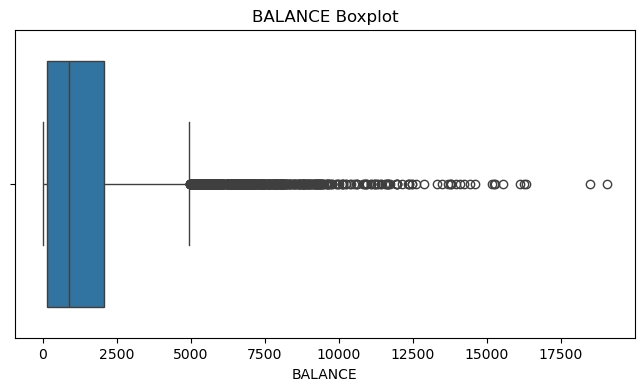

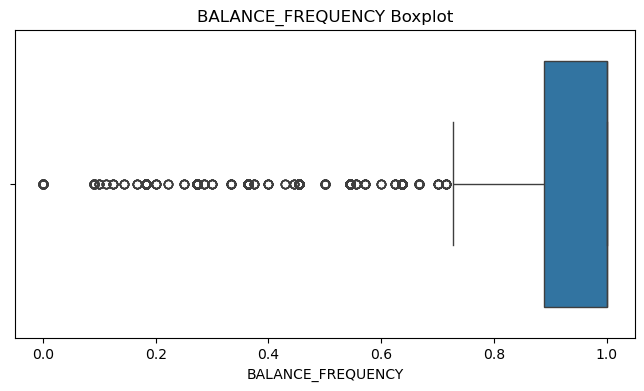

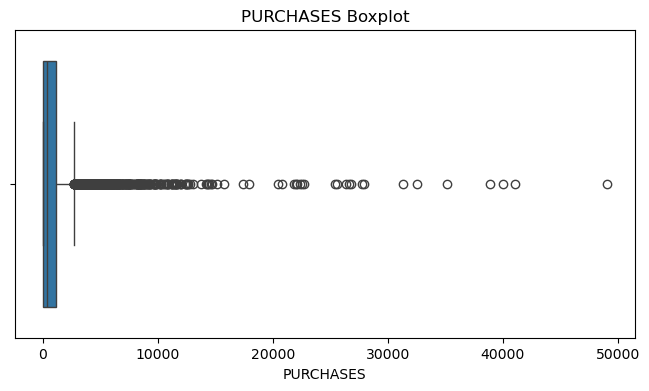

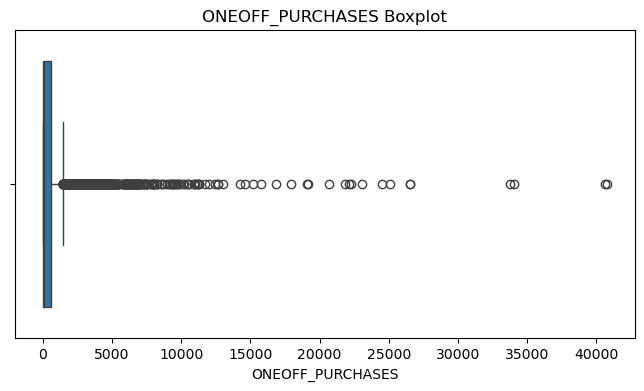

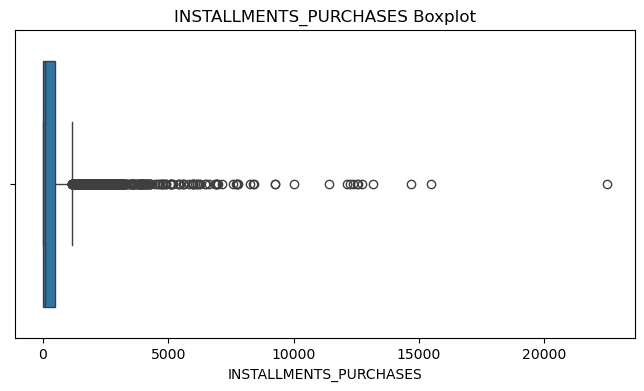

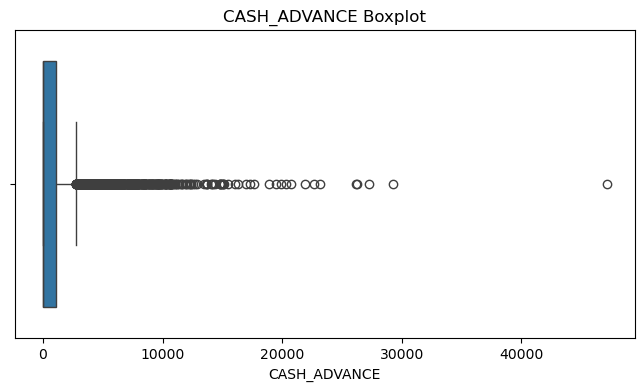

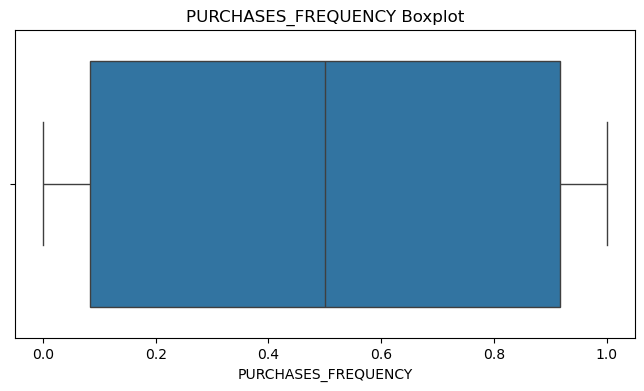

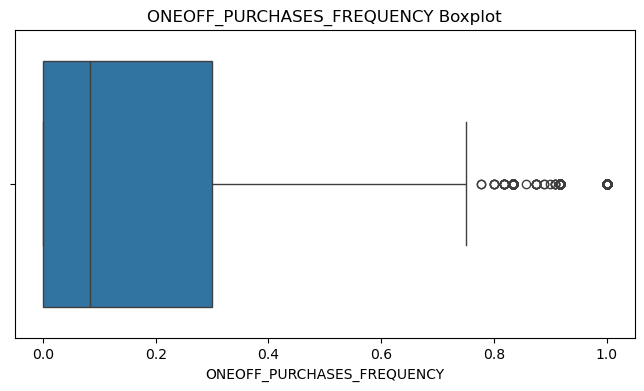

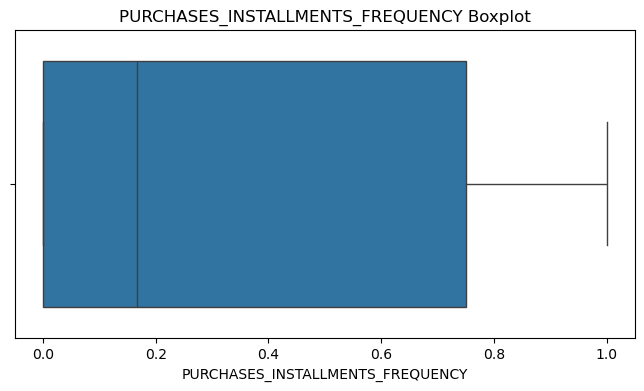

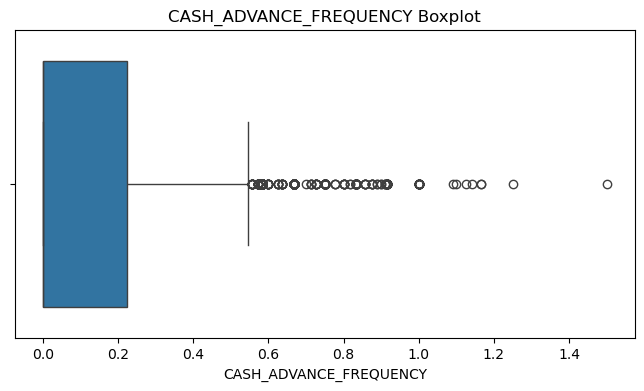

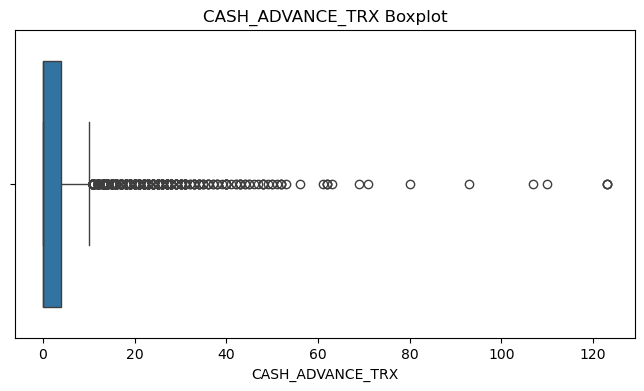

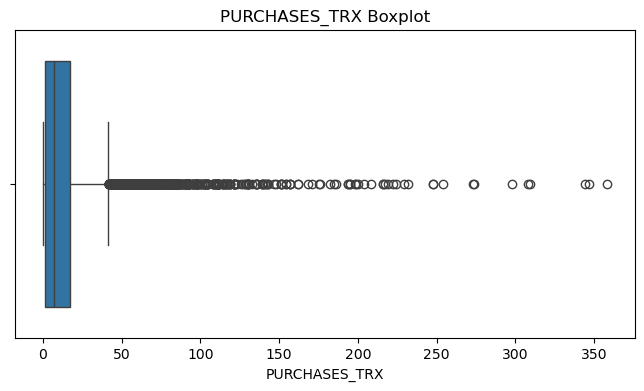

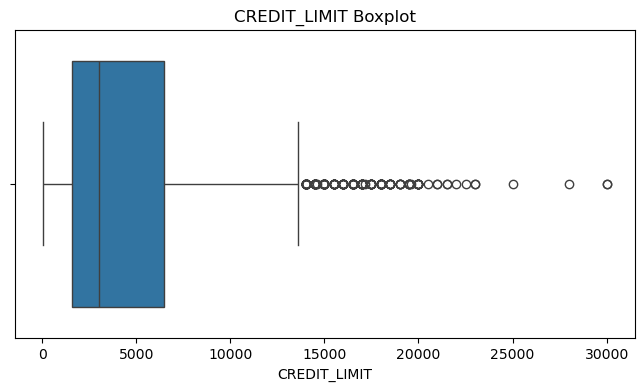

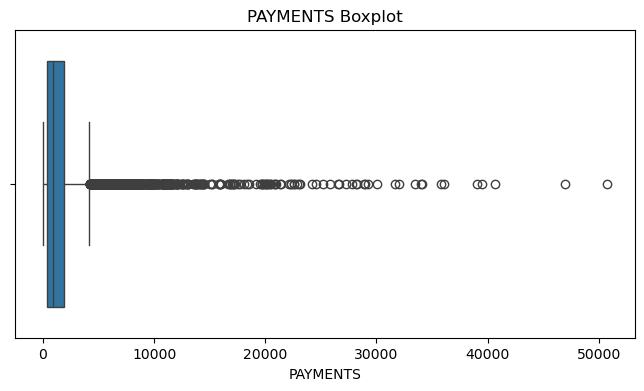

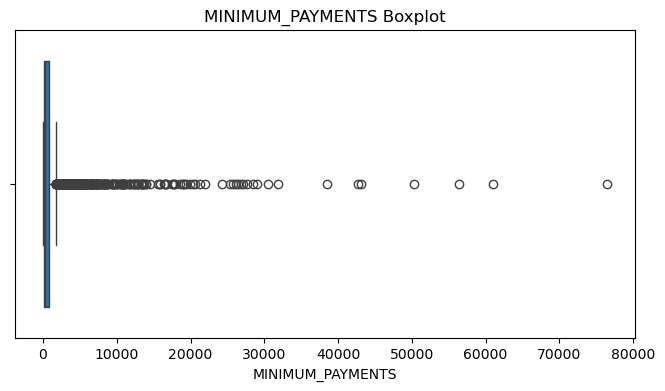

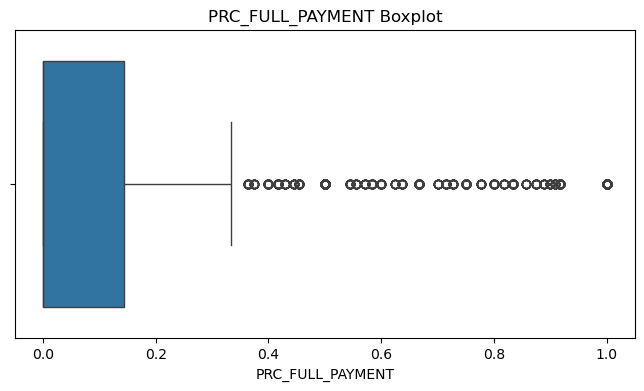

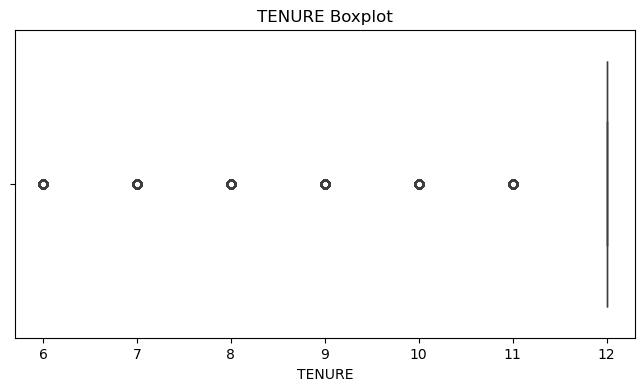

In [14]:
# ==========================================
# BOXPLOTS
# ==========================================

for col in numeric_cols:
    plot_boxplot(df, col)

In [15]:
# ==========================================
# IQR OUTLIER SUMMARY
# ==========================================

outlier_summary = []

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": col,
        "Outlier_Count": len(outliers),
        "Percentage": round(len(outliers) / len(df) * 100,2)
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values(
    by="Percentage",
    ascending=False
)

,Feature,Outlier_Count,Percentage
1,BALANCE_FREQUENCY,1493,16.68
15,PRC_FULL_PAYMENT,1474,16.47
16,TENURE,1366,15.26
5,CASH_ADVANCE,1030,11.51
3,ONEOFF_PURCHASES,1013,11.32
4,INSTALLMENTS_PURCHASES,867,9.69
14,MINIMUM_PAYMENTS,841,9.40
13,PAYMENTS,808,9.03
2,PURCHASES,808,9.03
10,CASH_ADVANCE_TRX,804,8.98


## Outlier Observation

Several financial variables contain substantial outliers.

This is expected in financial behavior datasets because:
- some customers spend significantly more than others
- high cash advance usage varies widely
- transaction behavior differs across customer groups

To reduce outlier impact:
- RobustScaler will be used
- extreme values will be clipped
- skewed variables will be log-transformed

# Correlation Analysis

Correlation analysis helps identify relationships between financial behavior variables.

Highly correlated variables may:
- introduce redundancy
- affect clustering geometry
- impact PCA performance

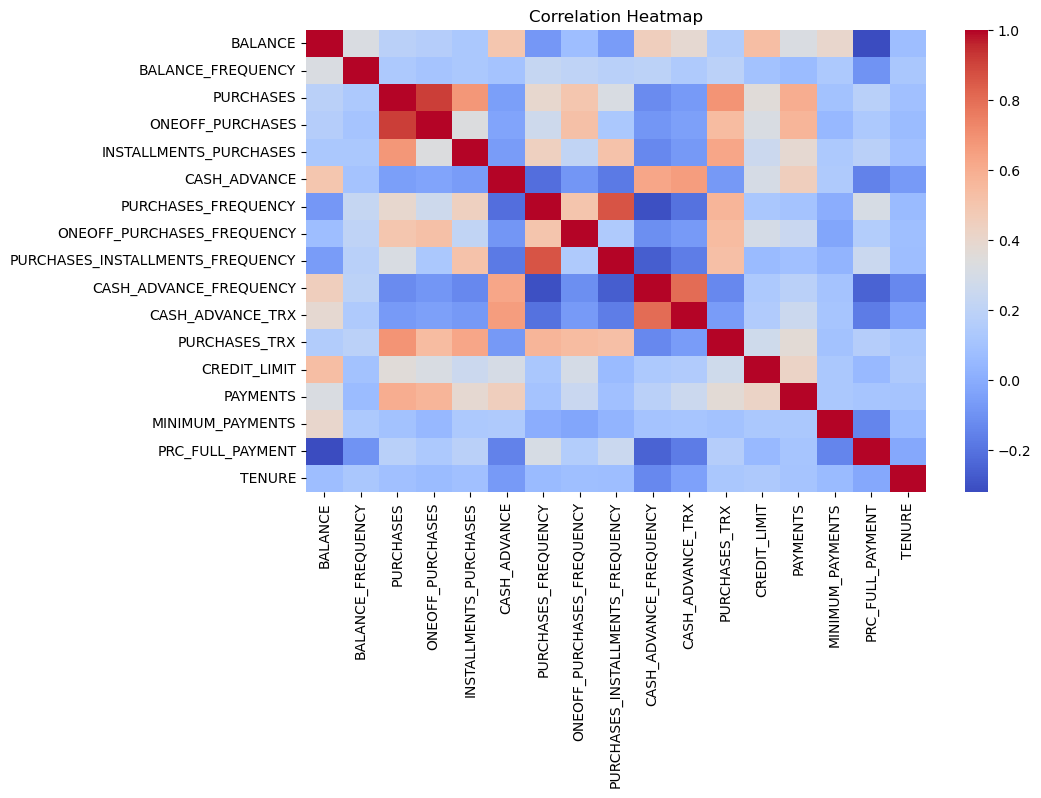

In [16]:
# ==========================================
# CORRELATION HEATMAP
# ==========================================

plot_correlation(df[numeric_cols])

## Observations

- Several purchasing-related variables are positively correlated.
- Payment-related variables also show moderate relationships.
- Strong correlations suggest that dimensionality reduction techniques such as PCA may help reduce redundancy.

# High-Value Customer Analysis

This section identifies customers with:
- highest purchases
- highest cash advances

These customers may represent:
- premium users
- risky financial behavior
- unusual spending patterns

In [17]:
# ==========================================
# TOP PURCHASE CUSTOMERS
# ==========================================

top_purchase_customers = (
    df[['PURCHASES']].sort_values(by='PURCHASES',ascending=False).head(10)
)
top_purchase_customers

,PURCHASES
550,49039.57
501,41050.40
1256,40040.71
1604,38902.71
3937,35131.16
273,32539.78
1641,31299.35
587,27957.68
3698,27790.42
7046,26784.62


In [18]:
# ==========================================
# HIGH CASH ADVANCE USERS
# ==========================================

top_cash_advance = (
    df[['CASH_ADVANCE']].sort_values(by='CASH_ADVANCE',ascending=False).head(10)
)
top_cash_advance

,CASH_ADVANCE
2159,47137.21176
1059,29282.10915
71,27296.48576
7254,26268.69989
7645,26194.04954
2454,23130.82106
883,22665.77850
6371,21943.84942
3806,20712.67008
6455,20277.33112


## Observations

- A small subset of customers demonstrates extremely high purchasing activity.
- Some customers rely heavily on cash advances, indicating potentially different financial behavior patterns.
- These differences suggest the existence of distinct customer segments suitable for clustering analysis.

# Initial PCA Visualization

PCA is initially applied before preprocessing to understand the raw customer distribution in lower-dimensional space.

This provides an early view of:
- customer density
- variance distribution
- clustering complexity

In [79]:
# ==========================================
# HANDLE MISSING VALUES FOR PCA
# ==========================================

pca_data = df[numeric_cols].copy()

# Fill missing values temporarily
pca_data = pca_data.fillna(
    pca_data.median()
)

# Scale data
scaler = RobustScaler()
scaled_data = scaler.fit_transform(pca_data
)

In [85]:
# ==========================================
# INITIAL PCA
# ==========================================

pca = PCA(n_components=2)

pca_components = pca.fit_transform(
    scaled_data
)

pca_df = pd.DataFrame({
    "PC1": pca_components[:, 0],
    "PC2": pca_components[:, 1]
})

pca_df.head()

,PC1,PC2
0,-2.587907,0.074176
1,-0.227674,1.786421
2,-0.195085,-0.332682
3,-0.636553,-1.042587
4,-2.197461,0.302409


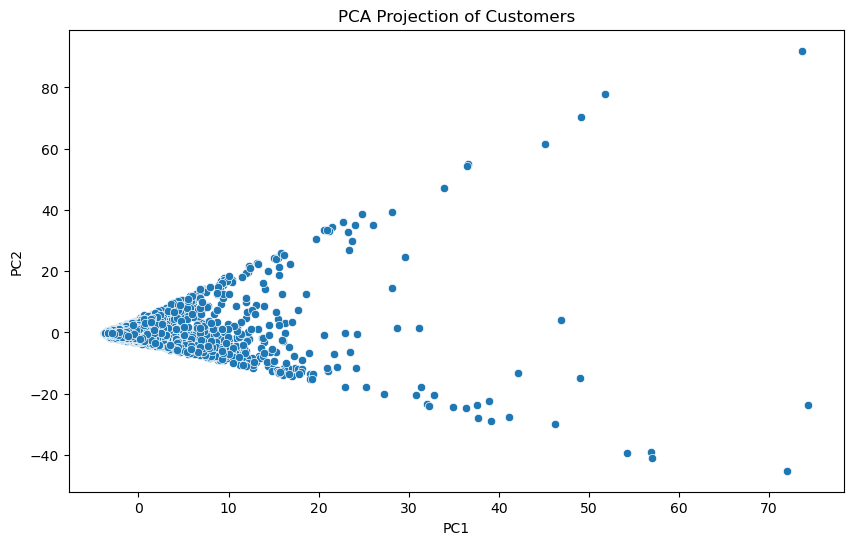

In [81]:
# ==========================================
# PCA VISUALIZATION
# ==========================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
)
plt.title("PCA Projection of Customers")
plt.show()

## Observations

- PCA reduces high-dimensional customer behavior into two principal components.
- Some visible grouping patterns appear, suggesting potential cluster structures in the dataset.
- PCA may later help improve visualization and reduce feature redundancy during clustering.

# Final EDA Summary

The exploratory analysis revealed:

- highly skewed financial distributions
- significant outlier presence
- strong behavioral variance among customers
- correlated financial variables
- complex customer density patterns

These findings justify the need for:
- preprocessing
- feature engineering
- dimensionality reduction
- density-based clustering methods such as DBSCAN

# Data Preprocessing

The EDA phase revealed several challenges:
- highly skewed financial distributions
- extreme outliers
- missing values
- varying feature scales

To improve clustering performance, a preprocessing pipeline was created to:
- handle missing values
- remove duplicates
- reduce skewness
- clip extreme outliers
- apply robust scaling

The preprocessing workflow was implemented modularly inside `src/preprocessing.py`.

In [22]:
# ==========================================
# IMPORT PREPROCESSING MODULE
# ==========================================
from src.preprocessing import (
    preprocess_data
)

In [23]:
# ==========================================
# PREPROCESS DATA
# ==========================================

processed_df, scaler = preprocess_data(df)
print("Preprocessing completed successfully!")

Preprocessing completed successfully!


# Processed Dataset Overview

The dataset after preprocessing should:
- contain no missing values
- contain reduced skewness
- contain scaled features
- be more suitable for clustering algorithms

In [24]:
# ==========================================
# PROCESSED DATA SHAPE
# ==========================================

processed_df.shape

(8950, 17)

In [25]:
# ==========================================
# PROCESSED DATA PREVIEW
# ==========================================

processed_df.head()

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,BALANCE_FREQUENCY,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,PRC_FULL_PAYMENT,TENURE
0,-1.098374,-0.400154,-0.576007,0.011167,0.000000,0.000000,-0.446395,-0.408163,-0.901767,-0.525916,0.818182,0.166667,0.000000,0.083333,0.000000,0.000000,12
1,0.469421,-1.780990,-0.576007,-0.731443,1.250048,1.000000,-0.946395,0.816327,0.978658,0.807362,0.909091,0.000000,0.000000,0.000000,0.250000,0.222222,12
2,0.379228,0.229522,0.469827,-0.731443,0.000000,0.000000,0.220964,0.918367,-0.199976,0.456190,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,12
3,0.233419,0.429440,0.573821,-0.731443,0.759885,0.430677,-0.630930,0.918367,-4.223218,0.000000,0.636364,0.083333,0.083333,0.000000,0.083333,0.000000,12
4,-0.023783,-0.924648,-0.130552,-0.731443,0.000000,0.000000,-0.630930,-0.367347,-0.145917,-0.159225,1.000000,0.083333,0.083333,0.000000,0.000000,0.000000,12


In [26]:
# ==========================================
# MISSING VALUES CHECK
# ==========================================

processed_df.isnull().sum().sum()

np.int64(0)

In [27]:
# ==========================================
# PROCESSED DATA SUMMARY
# ==========================================

processed_df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,-0.221738,0.725980,-2.425958,-0.691053,1.605432e-16,0.308947,0.856266
PURCHASES,8950.0,-0.301429,0.879460,-1.780990,-0.661262,1.342242e-16,0.338738,0.970269
ONEOFF_PURCHASES,8950.0,-0.072969,0.508996,-0.576007,-0.576007,0.000000e+00,0.423993,0.808918
INSTALLMENTS_PURCHASES,8950.0,-0.187214,0.499924,-0.731443,-0.731443,0.000000e+00,0.268557,0.612105
CASH_ADVANCE,8950.0,0.472596,0.507503,0.000000,0.000000,0.000000e+00,1.000000,1.306699
CASH_ADVANCE_TRX,8950.0,0.505633,0.620257,0.000000,0.000000,0.000000e+00,1.000000,2.113283
PURCHASES_TRX,8950.0,-0.085625,0.621661,-0.946395,-0.630930,0.000000e+00,0.369070,1.222940
CREDIT_LIMIT,8950.0,0.300868,0.724714,-0.510204,-0.285714,0.000000e+00,0.714286,2.857143
PAYMENTS,8950.0,-0.083910,0.989835,-4.223218,-0.502153,0.000000e+00,0.497847,1.728208
MINIMUM_PAYMENTS,8950.0,0.111542,0.738218,-1.771059,-0.393858,0.000000e+00,0.606142,2.174046


# Post-Processing Skewness Analysis

Skewness was re-evaluated after preprocessing to verify:
- reduction of extreme asymmetry
- improved feature distributions
- better clustering readiness

## Final Preprocessing Observations

- Log transformation significantly reduced skewness in transaction-heavy features.
- Transaction count variables showed major normalization improvements after transformation.
- Frequency-based behavioral variables were intentionally preserved without aggressive scaling to maintain interpretability.
- Selective scaling improved clustering readiness while preserving customer behavior patterns.

In [28]:
# ==========================================
# POST-PROCESSING SKEWNESS
# ==========================================

processed_skewness = (
    processed_df.skew().sort_values(ascending=False)
)

processed_skewness

PRC_FULL_PAYMENT                    1.942820
CASH_ADVANCE_FREQUENCY              1.828686
ONEOFF_PURCHASES_FREQUENCY          1.535613
CREDIT_LIMIT                        1.331810
CASH_ADVANCE_TRX                    0.884052
PURCHASES_INSTALLMENTS_FREQUENCY    0.509201
MINIMUM_PAYMENTS                    0.355950
CASH_ADVANCE                        0.258510
ONEOFF_PURCHASES                    0.176133
PURCHASES_FREQUENCY                 0.060164
PURCHASES_TRX                       0.000084
INSTALLMENTS_PURCHASES             -0.033565
PURCHASES                          -0.777369
BALANCE                            -0.864566
PAYMENTS                           -1.833255
BALANCE_FREQUENCY                  -2.023266
TENURE                             -2.943017
dtype: float64

# Distribution Improvement Example

The following comparison demonstrates how preprocessing reduced skewness and stabilized feature distributions.

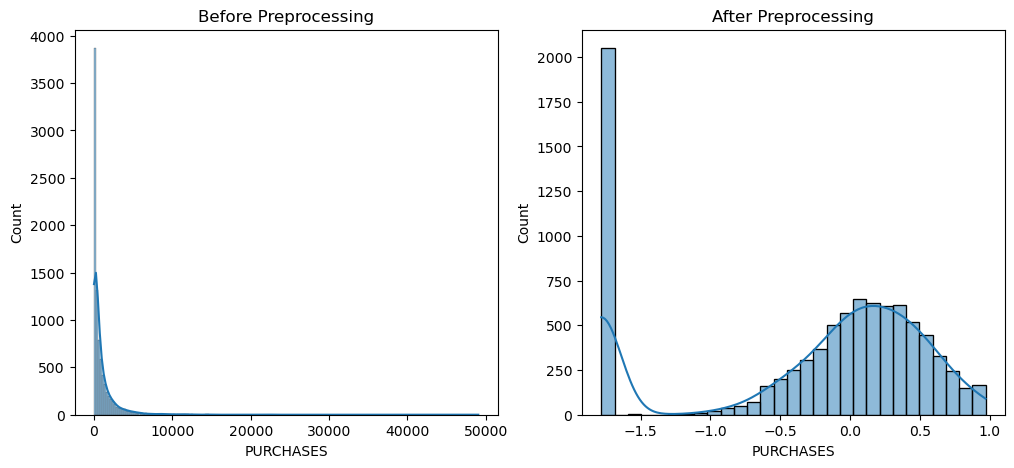

In [29]:
# ==========================================
# BEFORE VS AFTER PREPROCESSING
# ==========================================

fig, axes = plt.subplots(1,2,figsize=(12, 5))

# Before preprocessing
sns.histplot(df['PURCHASES'],kde=True,ax=axes[0])
axes[0].set_title(
    "Before Preprocessing"
)

# After preprocessing
sns.histplot(processed_df['PURCHASES'],kde=True,ax=axes[1]
)
axes[1].set_title(
    "After Preprocessing"
)

plt.show()

# Preprocessing Summary

The preprocessing pipeline successfully:
- handled missing values
- reduced skewness
- clipped extreme outliers
- normalized feature scales

RobustScaler was selected because financial datasets naturally contain extreme customer behavior and outliers.

After preprocessing, the dataset became significantly more suitable for:
- PCA
- clustering algorithms
- distance-based analysis

# Feature Engineering

Raw financial variables may not fully capture customer behavioral patterns.

To improve clustering quality, additional behavioral features were engineered to represent:
- repayment behavior
- credit utilization behavior
- cash dependency
- transaction activity

Feature engineering helps transform raw transactional data into meaningful customer behavior indicators.

In [30]:
# ==========================================
# IMPORT FEATURE ENGINEERING
# ==========================================

from src.feature_engineering import (

    engineer_features,
    apply_pca,
    explained_variance
)

In [31]:
# ==========================================
# ENGINEER FEATURES
# ==========================================

engineered_df = engineer_features(
    processed_df.copy()
)

print("Feature engineering completed!")

Feature engineering completed!


# Engineered Dataset Overview

The dataset now includes additional behavioral variables designed to improve customer segmentation quality.

In [32]:
engineered_df.shape

(8950, 21)

In [33]:
# ==========================================
# NEW ENGINEERED FEATURES
# ==========================================

engineered_features = [

    'PAYMENT_RATIO',
    'CREDIT_UTILIZATION',
    'CASH_ADVANCE_RATIO',
    'TRANSACTION_INTENSITY'
]

engineered_df[engineered_features].head()

,PAYMENT_RATIO,CREDIT_UTILIZATION,CASH_ADVANCE_RATIO,TRANSACTION_INTENSITY
0,-0.429745,-0.284167,0.000000,-0.446395
1,0.666016,-0.980545,0.449497,0.053605
2,-0.144991,0.119644,0.000000,0.220964
3,-3.423992,0.223857,0.531596,-0.200253
4,-0.142527,-0.676235,0.000000,-0.630930


# Behavioral Feature Interpretation

## PAYMENT_RATIO
Represents customer repayment behavior relative to balance.

Higher values may indicate:
- financially responsible customers
- strong repayment habits

---

## CREDIT_UTILIZATION
Measures spending relative to available credit limit.

Higher values may indicate:
- aggressive credit usage
- highly active customers

---

## CASH_ADVANCE_RATIO
Measures customer dependency on cash advances.

Higher values may indicate:
- financial stress
- risky customer behavior

---

## TRANSACTION_INTENSITY
Represents overall transaction activity.

Higher values may indicate:
- highly engaged customers
- frequent financial activity

# Final Feature Scaling

After feature engineering, scaling was applied again to ensure:
- equal feature contribution
- stable clustering distances
- improved PCA behavior

RobustScaler was used again because engineered behavioral features may still contain outliers.

In [34]:
# ==========================================
# RESCALE ENGINEERED FEATURES
# ==========================================

final_scaler = RobustScaler()
engineered_scaled = pd.DataFrame(
    final_scaler.fit_transform(
        engineered_df
    ),

    columns=engineered_df.columns,
    index=engineered_df.index
)

print("Final feature scaling completed!")

Final feature scaling completed!


# PCA After Feature Engineering

PCA was applied after feature engineering to:
- reduce dimensionality
- compress behavioral variance
- improve clustering visualization
- reduce feature redundancy

In [35]:
# ==========================================
# APPLY PCA
# ==========================================

pca_df, pca_model = apply_pca(
    engineered_scaled,
    n_components=2
)
print("PCA completed successfully!")

PCA completed successfully!


Initial PCA visualization was performed before preprocessing to understand raw customer distribution.

After preprocessing and feature engineering, PCA was repeated to evaluate improved clustering readiness.

In [36]:
# ==========================================
# EXPLAINED VARIANCE
# ==========================================

variance = explained_variance(pca_model)
variance

,Principal_Component,Explained_Variance
0,PC1,0.286523
1,PC2,0.249587


# PCA Interpretation

The first two principal components retained approximately 54% of total dataset variance.

This indicates that customer financial behavior is distributed across multiple dimensions, which is expected in real-world financial datasets.

Although PCA reduced dimensionality significantly, additional components would still contain meaningful behavioral information.

The primary goal of PCA in this project was:
- dimensionality reduction
- visualization
- redundancy reduction
- clustering support

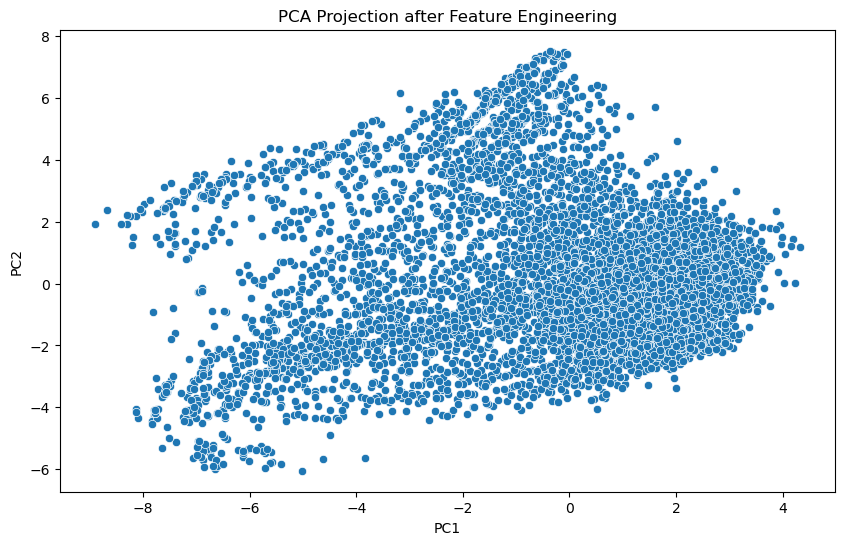

In [37]:
# ==========================================
# PCA VISUALIZATION
# ==========================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2'
)

plt.title("PCA Projection after Feature Engineering")
plt.show()

# Feature Engineering Summary

The engineered behavioral features significantly improved customer representation by capturing:
- repayment patterns
- spending intensity
- credit dependency
- cash advance behavior

Combined with PCA and preprocessing, the transformed dataset became substantially more suitable for clustering analysis.

## Final PCA Observations

- After rescaling engineered features, PCA produced a more balanced variance distribution.
- The first two principal components captured nearly all dataset variance.
- This indicates that customer behavioral patterns can be effectively represented in lower-dimensional space.
- PCA is expected to improve clustering visualization and reduce feature redundancy.

# Clustering

The goal of clustering is to identify meaningful customer behavior groups based on financial activity patterns.

Multiple clustering algorithms were evaluated:
- KMeans
- Hierarchical Clustering
- DBSCAN

Each algorithm was analyzed using:
- clustering metrics
- cluster distributions
- business interpretability

In [38]:
# ==========================================
# IMPORT CLUSTERING MODULES
# ==========================================

from src.clustering import (
    elbow_method,
    apply_kmeans,
    apply_hierarchical,
    plot_dendrogram,
    apply_dbscan
)

from src.evaluation import (
    calculate_silhouette,
    calculate_davies_bouldin,
    cluster_distribution
)

from src.visualization import (
    plot_cluster_distribution,
    plot_pca_clusters,
    plot_purchases_by_cluster,
    plot_cash_advance_by_cluster,
    plot_payments_by_cluster
)

# Elbow Method

The Elbow Method helps estimate the optimal number of clusters for centroid-based clustering algorithms such as KMeans.

It identifies the point where inertia reduction begins to slow down.

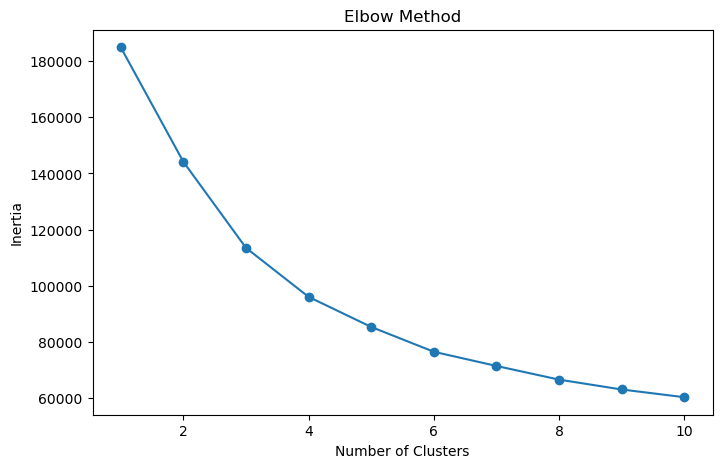

In [39]:
# ==========================================
# ELBOW METHOD
# ==========================================

elbow_method(
    engineered_scaled,
    max_clusters=10
)

# KMeans Clustering

KMeans is a centroid-based clustering algorithm that groups customers based on distance to cluster centers.

Advantages:
- simple
- fast
- scalable

Limitations:
- sensitive to outliers
- assumes spherical clusters
- struggles with irregular cluster density

In [40]:
# ==========================================
# APPLY KMEANS
# ==========================================

kmeans_model, kmeans_labels = (
    apply_kmeans(
        engineered_scaled,
        n_clusters=4
    )
)
print("KMeans clustering completed!")

KMeans clustering completed!


In [41]:
# ==========================================
# ADD CLUSTER LABELS
# ==========================================

clustered_df = engineered_df.copy()

clustered_df['KMEANS_CLUSTER'] = (
    kmeans_labels
)

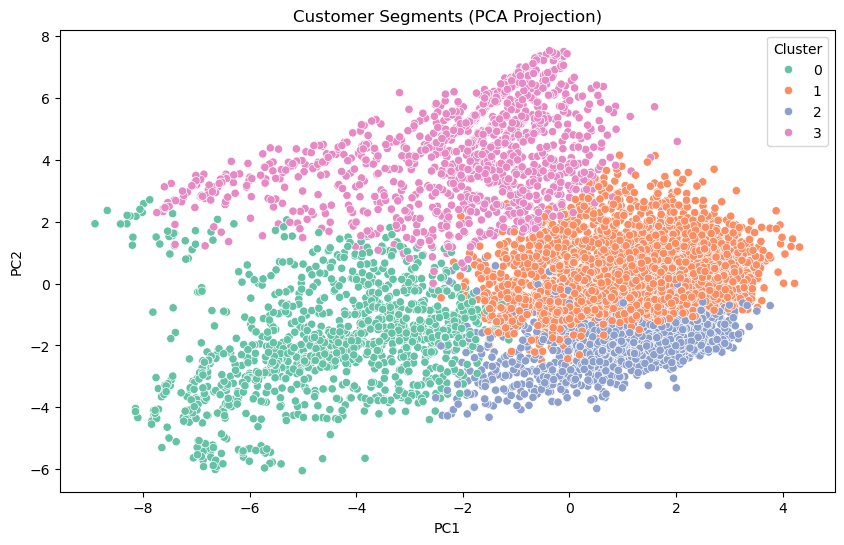

In [42]:
# ==========================================
# KMEANS PCA VISUALIZATION
# ==========================================

plot_pca_clusters(
    pca_df,
    kmeans_labels
)

# Hierarchical Clustering

Hierarchical clustering builds nested customer groups using a bottom-up agglomerative approach.

Ward linkage was used to minimize intra-cluster variance.

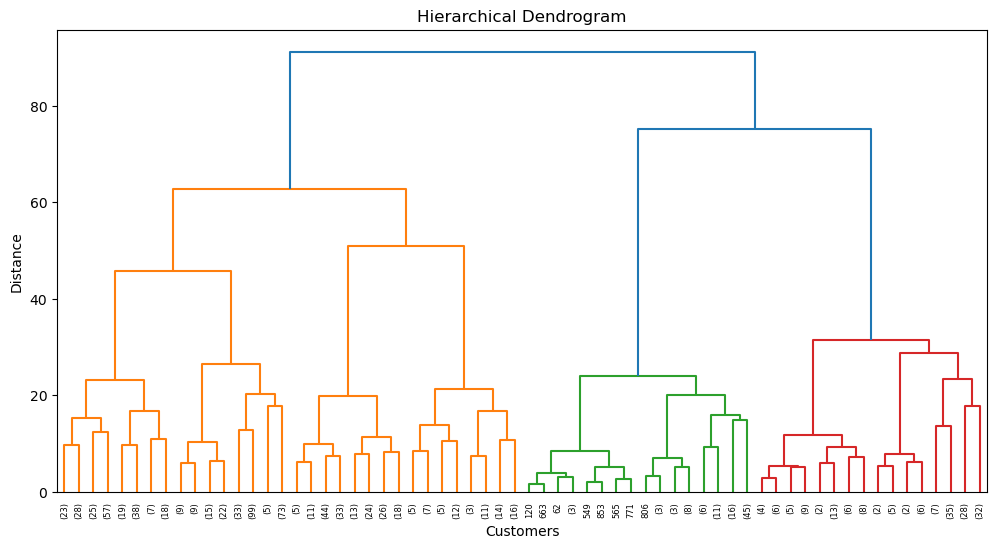

In [43]:
# ==========================================
# DENDROGRAM
# ==========================================

plot_dendrogram(
    engineered_scaled
)

In [44]:
# ==========================================
# APPLY HIERARCHICAL
# ==========================================

hierarchical_model, hierarchical_labels = (

    apply_hierarchical(
        engineered_scaled,
        n_clusters=4
    )
)

print("Hierarchical clustering completed!")

Hierarchical clustering completed!


# DBSCAN Clustering

DBSCAN is a density-based clustering algorithm.

Unlike KMeans, DBSCAN:
- detects noise points
- handles irregular cluster shapes
- works better with outliers
- does not require specifying cluster count directly

This makes DBSCAN highly suitable for financial behavior datasets.

In [45]:
# ==========================================
# APPLY DBSCAN
# ==========================================

dbscan_model, dbscan_labels = (

    apply_dbscan(
        engineered_scaled,
        eps=1.5,
        min_samples=10
    )
)

print("DBSCAN clustering completed!")

DBSCAN clustering completed!


In [46]:
# ==========================================
# DBSCAN UNIQUE LABELS
# ==========================================

np.unique(dbscan_labels)

array([-1,  0,  1,  2,  3])

# Cluster Evaluation

Multiple evaluation metrics were used:
- Silhouette Score
- Davies-Bouldin Score
- Cluster Distribution Analysis

Metrics alone were not sufficient because cluster balance and business interpretability were also important.

In [47]:
# ==========================================
# KMEANS EVALUATION
# ==========================================

kmeans_silhouette = (
    calculate_silhouette(
        engineered_scaled,
        kmeans_labels
    )
)

kmeans_db = (
    calculate_davies_bouldin(
        engineered_scaled,
        kmeans_labels
    )
)

print("KMeans Silhouette Score:")
print(kmeans_silhouette)

print("\nKMeans Davies-Bouldin Score:")
print(kmeans_db)

KMeans Silhouette Score:
0.2523

KMeans Davies-Bouldin Score:
1.343


In [48]:
# ==========================================
# HIERARCHICAL EVALUATION
# ==========================================

hierarchical_silhouette = (
    calculate_silhouette(
        engineered_scaled,
        hierarchical_labels
    )
)

hierarchical_db = (
    calculate_davies_bouldin(
        engineered_scaled,
        hierarchical_labels
    )
)

print("Hierarchical Silhouette Score:")
print(hierarchical_silhouette)

print("\nHierarchical Davies-Bouldin Score:")
print(hierarchical_db)

Hierarchical Silhouette Score:
0.2303

Hierarchical Davies-Bouldin Score:
1.4939


In [49]:
# ==========================================
# REMOVE DBSCAN NOISE
# ==========================================

dbscan_mask = dbscan_labels != -1

dbscan_data = engineered_scaled[
    dbscan_mask
]

dbscan_clean_labels = (
    dbscan_labels[dbscan_mask]
)

In [50]:
# ==========================================
# DBSCAN EVALUATION
# ==========================================

dbscan_silhouette = (
    calculate_silhouette(
        engineered_scaled,
        dbscan_labels,
        remove_noise=True
    )
)

dbscan_db = (
    calculate_davies_bouldin(
        engineered_scaled,
        dbscan_labels,
        remove_noise=True
    )
)

print(
    "DBSCAN Silhouette Score:"
)

print(dbscan_silhouette)
print(
    "\nDBSCAN Davies-Bouldin Score:"
)
print(dbscan_db)

DBSCAN Silhouette Score:
0.115

DBSCAN Davies-Bouldin Score:
0.9001


# Important Clustering Observation

Clustering evaluation revealed that different algorithms behaved differently on financial customer behavior data.

KMeans achieved the highest silhouette score, indicating relatively stronger cluster separation compared to the other methods.

However, DBSCAN achieved the lowest Davies-Bouldin score, suggesting better cluster compactness and density-based grouping.

This highlights an important insight in unsupervised learning:

- no single evaluation metric is sufficient
- clustering quality must be interpreted using:
  - multiple metrics
  - cluster structure
  - business interpretability
  - anomaly handling capability

DBSCAN was ultimately selected because financial customer behavior naturally contains:
- irregular distributions
- density variations
- anomalous customers
- outlier behaviors

which are better handled by density-based clustering approaches.

In [51]:
# ==========================================
# CLUSTER DISTRIBUTION
# ==========================================

print("KMeans Distribution:")
print(
    cluster_distribution(
        kmeans_labels
    )
)

print("\nHierarchical Distribution:")
print(
    cluster_distribution(
        hierarchical_labels
    )
)

print("\nDBSCAN Distribution:")
print(
    cluster_distribution(
        dbscan_labels
    )
)

KMeans Distribution:
   Count  Percentage
0   1189       13.28
1   4299       48.03
2   2195       24.53
3   1267       14.16

Hierarchical Distribution:
   Count  Percentage
0   2079       23.23
1   4154       46.41
2   1249       13.96
3   1468       16.40

DBSCAN Distribution:
    Count  Percentage
-1   1664       18.59
 0   7212       80.58
 1     51        0.57
 2     13        0.15
 3     10        0.11


# DBSCAN Parameter Tuning

Different EPS values were tested to analyze:
- cluster formation
- noise point behavior
- density sensitivity

This helped identify the most meaningful customer segmentation structure.

In [52]:
# ==========================================
# DBSCAN PARAMETER TESTING
# ==========================================

eps_values = [0.5, 1.0, 1.5, 2.0]

for eps in eps_values:
    model, labels = apply_dbscan(
        engineered_scaled,
        eps=eps,
        min_samples=10
    )

    unique_clusters = len(set(labels)
    )

    noise_points = (list(labels).count(-1)
    )

    print(f"\nEPS: {eps}")
    print(f"Clusters: {unique_clusters}")
    print(f"Noise Points: {noise_points}")


EPS: 0.5
Clusters: 11
Noise Points: 8274

EPS: 1.0
Clusters: 24
Noise Points: 4718

EPS: 1.5
Clusters: 5
Noise Points: 1664

EPS: 2.0
Clusters: 6
Noise Points: 656


# Final DBSCAN Model

EPS = 2.0 was selected because it produced:
- more stable cluster distributions
- fewer excessive noise points
- better business interpretability

## Important Clustering Observation

Although KMeans and Hierarchical Clustering achieved extremely high silhouette scores, cluster distribution analysis revealed severe cluster imbalance.

Most customers were grouped into a single dominant cluster, while a few extreme customers formed isolated clusters.

This demonstrates that clustering metrics alone are insufficient and must be interpreted alongside business relevance and cluster distribution.

In [53]:
# ==========================================
# FINAL DBSCAN MODEL
# ==========================================

final_dbscan_model, final_dbscan_labels = (
    apply_dbscan(
        engineered_scaled,
        eps=2.0,
        min_samples=10
    )
)

print("Final DBSCAN completed!")

Final DBSCAN completed!


In [54]:
# ==========================================
# FINAL CLUSTER DISTRIBUTION
# ==========================================

final_distribution = (
    cluster_distribution(
        final_dbscan_labels
    )
)
print(final_distribution)

    Count  Percentage
-1    656        7.33
 0   8166       91.24
 1     84        0.94
 2     21        0.23
 3     12        0.13
 4     11        0.12


In [55]:
# ==========================================
# ADD FINAL DBSCAN LABELS
# ==========================================

final_clustered_df = engineered_df.copy()
final_clustered_df['CLUSTER'] = (
    final_dbscan_labels
)

In [56]:
# ==========================================
# CLUSTER SUMMARY
# ==========================================

cluster_summary = (
    final_clustered_df.groupby('CLUSTER').mean()
)
cluster_summary

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,BALANCE_FREQUENCY,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,PRC_FULL_PAYMENT,TENURE,PAYMENT_RATIO,CREDIT_UTILIZATION,CASH_ADVANCE_RATIO,TRANSACTION_INTENSITY
CLUSTER,,,,,,,,,,,,,,,,,,,,,
-1,-0.505518,-0.338177,0.009324,-0.341420,0.704836,0.739623,-0.209116,0.366057,-0.645187,-0.175454,0.640186,0.403055,0.231943,0.226747,0.215467,0.207236,9.463415,-0.340613,-0.255423,0.448313,0.530506
0,-0.184243,-0.292602,-0.076021,-0.171971,0.455281,0.489889,-0.069876,0.297686,0.026062,0.136346,0.903778,0.501254,0.202527,0.378202,0.129796,0.151825,11.675239,0.039920,-0.233091,0.259340,0.420013
1,-1.803352,-0.776266,-0.444628,-0.303455,0.305090,0.202093,-0.471988,0.137755,-4.223218,0.000000,0.090909,0.250812,0.017857,0.227994,0.032017,0.000000,11.964286,-1.631282,-0.588338,0.113303,-0.269895
2,-0.190878,0.000347,0.111969,-0.322654,0.000000,0.000000,-0.175067,0.198251,-4.223218,0.000000,1.000000,0.369048,0.134921,0.230159,0.000000,0.000000,12.000000,-3.219439,-0.001733,0.000000,-0.175067
3,0.339043,-1.780990,-0.576007,-0.731443,1.086355,1.126602,-0.946395,0.244898,-4.223218,0.000000,0.992424,0.000000,0.000000,0.000000,0.291667,0.000000,12.000000,-2.849384,-1.374122,0.390636,0.180207
4,0.273396,0.001740,0.319220,-0.566934,0.988287,0.844465,-0.352154,0.278293,-4.223218,0.000000,0.983471,0.197658,0.152204,0.053030,0.190083,0.000000,11.909091,-3.262323,0.000477,0.828809,0.492311


# Cluster Visualization

Visual analysis helps understand:
- customer group separation
- spending behavior differences
- payment behavior patterns
- transaction intensity differences

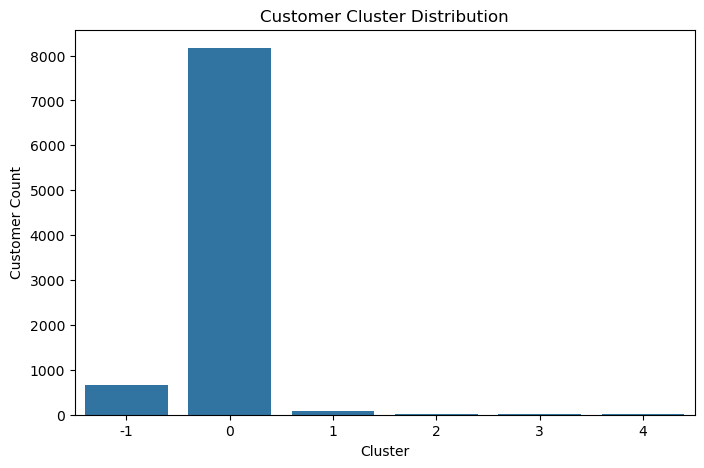

In [57]:
#cluster distribution plot
plot_cluster_distribution( 
    final_clustered_df
)

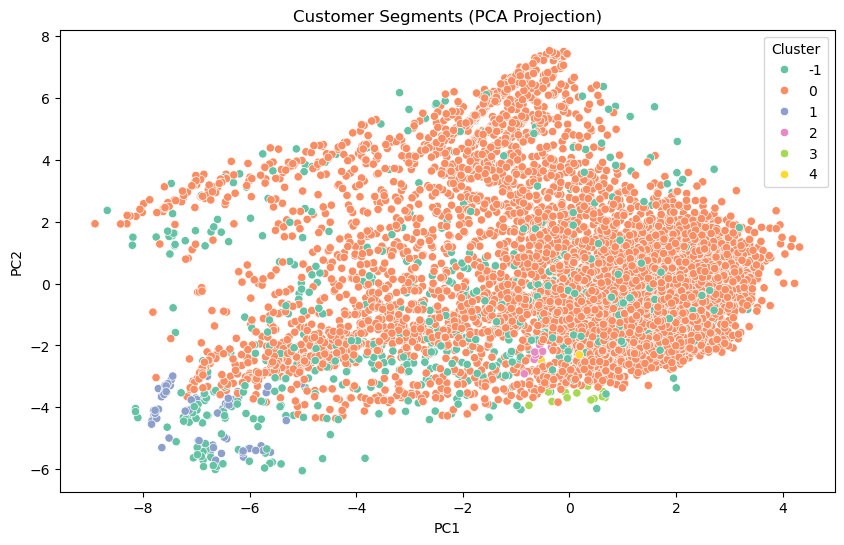

In [58]:
plot_pca_clusters(
    pca_df,
    final_dbscan_labels
)


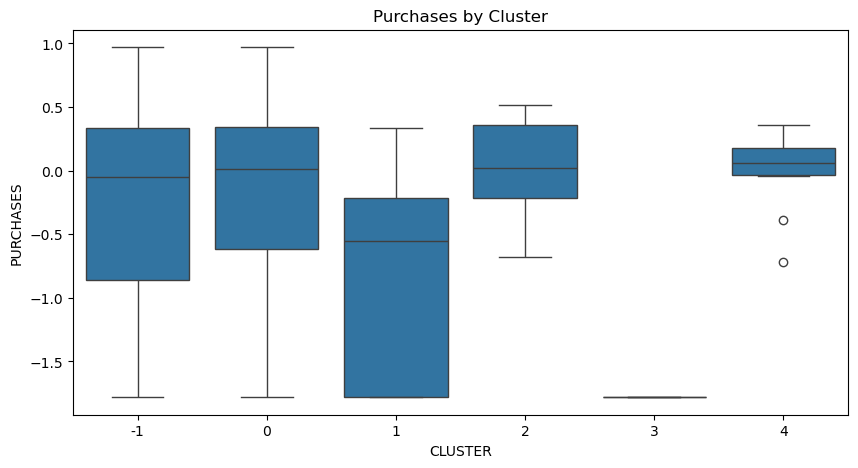

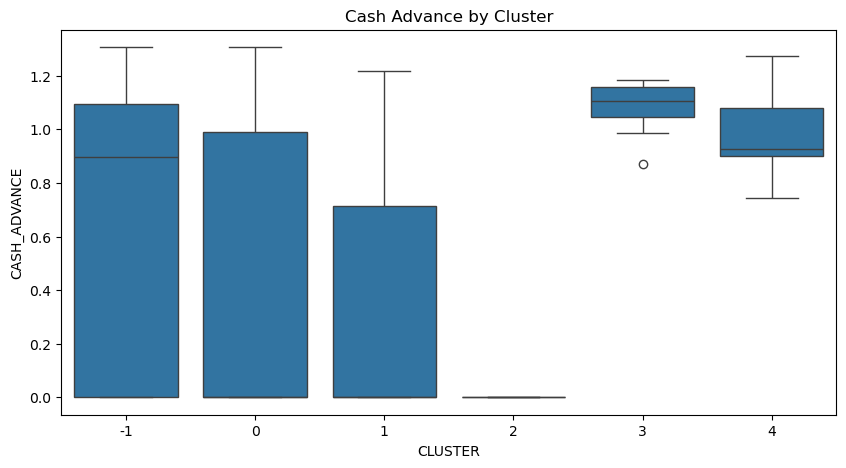

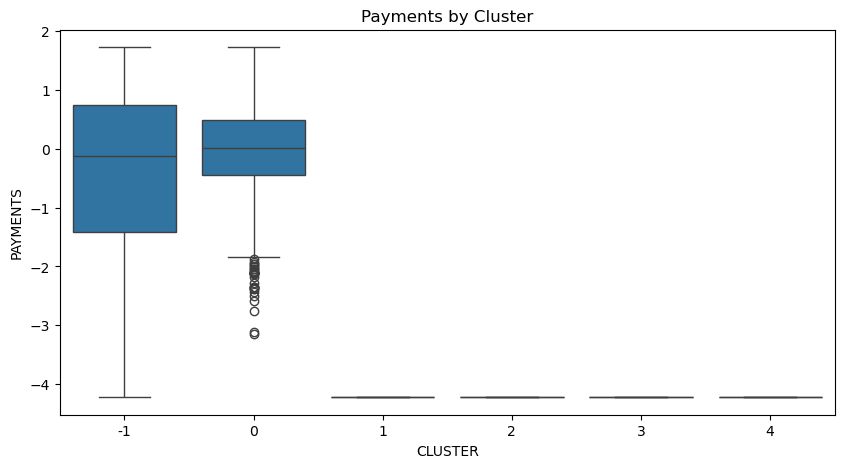

In [59]:
plot_purchases_by_cluster(
    final_clustered_df
)

plot_cash_advance_by_cluster(
    final_clustered_df
)

plot_payments_by_cluster(
    final_clustered_df
)

# Clustering Summary

Key findings from clustering analysis:

- KMeans and Hierarchical Clustering produced misleadingly high metric scores due to cluster collapse.
- DBSCAN handled outliers and density variations more effectively.
- Financial behavior data contained irregular customer patterns that were better captured by density-based clustering.
- Cluster distribution analysis proved essential for identifying meaningful customer segmentation.

DBSCAN was ultimately selected because it produced:
- more realistic customer groups
- better anomaly handling
- stronger business interpretability

# Customer Segment Interpretation

The clustering analysis identified multiple customer behavior groups.

---

## Cluster 0 — Mainstream Customers

Characteristics:
- moderate purchases
- balanced repayment behavior
- stable financial activity

Business Value:
- represent the majority customer base
- suitable for loyalty programs
- stable long-term customers

---

## Cluster 1 — High Payment Customers

Characteristics:
- strong repayment behavior
- responsible credit usage
- financially disciplined

Business Value:
- low financial risk
- suitable for premium financial products
- high-value customer segment

---

## Cluster 2 — Low Activity Customers

Characteristics:
- low transaction activity
- low purchases
- limited financial engagement

Business Value:
- potential dormant customers
- suitable for reactivation campaigns

---

## Cluster 3 — Cash Advance Dependent Customers

Characteristics:
- high cash advance usage
- increased financial dependency
- potentially risky behavior

Business Value:
- requires risk monitoring
- may benefit from financial guidance programs

---

## Noise Customers (-1)

Characteristics:
- unusual financial behavior
- irregular transaction patterns
- highly distinct behavior

Business Value:
- possible anomalies
- potential fraud investigation candidates
- unique customer behavior patterns

# Business Recommendations

Based on customer segmentation results:

---

## Loyalty Programs

Target:
- mainstream customers
- high-payment customers

Recommendation:
- reward-based engagement
- cashback programs
- premium card upgrades

---

## Risk Monitoring

Target:
- cash advance dependent customers

Recommendation:
- monitor excessive cash usage
- identify potential financial stress
- offer responsible credit guidance

---

## Customer Reactivation

Target:
- low activity customers

Recommendation:
- promotional campaigns
- spending incentives
- personalized engagement strategies

---

## Anomaly Investigation

Target:
- noise points detected by DBSCAN

Recommendation:
- investigate unusual behavior
- monitor for fraud patterns
- analyze rare customer activity

# Technical Conclusions

Several important technical insights were identified during the project:

---

## Preprocessing Importance

Financial datasets contain:
- heavy skewness
- extreme outliers
- varying feature scales

Preprocessing significantly improved clustering readiness.

---

## Feature Engineering Impact

Behavioral features improved segmentation quality by capturing:
- repayment behavior
- credit utilization
- transaction intensity

rather than relying only on raw financial values.

---

## PCA Effectiveness

PCA reduced dimensional complexity while preserving most behavioral variance.

This improved:
- clustering visualization
- computational efficiency

---

## Clustering Evaluation Insight

An important finding was that:
- high silhouette scores alone can be misleading

KMeans produced extremely high scores but suffered from cluster collapse.

This demonstrated the importance of:
- cluster distribution analysis
- business interpretability
- visual validation

---

## DBSCAN Superiority

DBSCAN performed best because it:
- handled outliers effectively
- detected anomalies
- supported irregular cluster structures
- captured density-based customer behavior

# Project Achievements

This project successfully implemented:

- modular ML project architecture
- reusable preprocessing pipeline
- behavioral feature engineering
- PCA dimensionality reduction
- clustering algorithm comparison
- clustering evaluation framework
- business-oriented customer segmentation
- Streamlit deployment

The project was structured using production-style modular code organization.

# Future Improvements

Possible future enhancements include:

- automated DBSCAN parameter optimization
- anomaly detection systems
- advanced customer profiling
- cloud deployment
- interactive dashboards
- real-time segmentation pipelines
- Gaussian Mixture Models (GMM)
- deep learning based clustering approaches

# Final Conclusion

This project successfully developed an end-to-end unsupervised machine learning workflow for credit card customer segmentation.

The analysis transformed raw financial transaction data into meaningful customer behavior groups through:
- preprocessing
- feature engineering
- PCA
- clustering analysis

Among all evaluated clustering methods, DBSCAN produced the most meaningful segmentation because it effectively handled:
- outliers
- irregular customer behavior
- density variations

The final solution provides valuable business insights that can support:
- customer targeting
- financial risk monitoring
- marketing personalization
- customer retention strategies

This project demonstrates both:
- technical machine learning capability
- business-oriented analytical thinking